## Step 1: Setup Library Imports
**Data Manipulation:** `pandas`, `numpy`
**Visualization:** `matplotlib`, `seaborn`
**Machine Learning:** `sklearn` (`KMeans`, `StandardScaler`)

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn import metrics
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
%matplotlib inline


## Step 2: Data Importing & Initial Overview
We will load the `USA_Housing.csv` dataset and inspect the first few rows to understand its  structure/layout.

In [2]:
df = pd.read_csv('USA_Housing.csv')

In [3]:
df.head()

,Avg. Area Income,Avg. Area House Age,Avg. Area Number of Rooms,Avg. Area Number of Bedrooms,Area Population,Price,Address
0,79545.458574,5.682861,7.009188,4.09,23086.800503,1.059034e+06,"208 Michael Ferry Apt. 674\nLaurabury, NE 3701..."
1,79248.642455,6.002900,6.730821,3.09,40173.072174,1.505891e+06,"188 Johnson Views Suite 079\nLake Kathleen, CA..."
2,61287.067179,5.865890,8.512727,5.13,36882.159400,1.058988e+06,"9127 Elizabeth Stravenue\nDanieltown, WI 06482..."
3,63345.240046,7.188236,5.586729,3.26,34310.242831,1.260617e+06,USS Barnett\nFPO AP 44820
4,59982.197226,5.040555,7.839388,4.23,26354.109472,6.309435e+05,USNS Raymond\nFPO AE 09386


## Step 3: Data Cleaning & Quality Assessment
Summary statistics and column info

Reading the data: feilds, descibing data, looking for missing values, looking for total bad data entries

cleaning data: removing, duplicates, removing null values

In [4]:
df.describe()

,Avg. Area Income,Avg. Area House Age,Avg. Area Number of Rooms,Avg. Area Number of Bedrooms,Area Population,Price
count,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5.000000e+03
mean,68583.108984,5.977222,6.987792,3.981330,36163.516039,1.232073e+06
std,10657.991214,0.991456,1.005833,1.234137,9925.650114,3.531176e+05
min,17796.631190,2.644304,3.236194,2.000000,172.610686,1.593866e+04
25%,61480.562388,5.322283,6.299250,3.140000,29403.928702,9.975771e+05
50%,68804.286404,5.970429,7.002902,4.050000,36199.406689,1.232669e+06
75%,75783.338666,6.650808,7.665871,4.490000,42861.290769,1.471210e+06
max,107701.748378,9.519088,10.759588,6.500000,69621.713378,2.469066e+06


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 7 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   Avg. Area Income              5000 non-null   float64
 1   Avg. Area House Age           5000 non-null   float64
 2   Avg. Area Number of Rooms     5000 non-null   float64
 3   Avg. Area Number of Bedrooms  5000 non-null   float64
 4   Area Population               5000 non-null   float64
 5   Price                         5000 non-null   float64
 6   Address                       5000 non-null   object 
dtypes: float64(6), object(1)
memory usage: 273.6+ KB


In [6]:
df.isnull().sum()

Avg. Area Income                0
Avg. Area House Age             0
Avg. Area Number of Rooms       0
Avg. Area Number of Bedrooms    0
Area Population                 0
Price                           0
Address                         0
dtype: int64

In [7]:
df = df.dropna()
df = df.drop_duplicates()
df = df.fillna(0)

In [8]:
df.isnull().sum()

Avg. Area Income                0
Avg. Area House Age             0
Avg. Area Number of Rooms       0
Avg. Area Number of Bedrooms    0
Area Population                 0
Price                           0
Address                         0
dtype: int64

## Step 4: Exploratory Data Analysis (EDA) & Visualizations
Explore feature distributions, relationships, and correlation factors across housing variables.

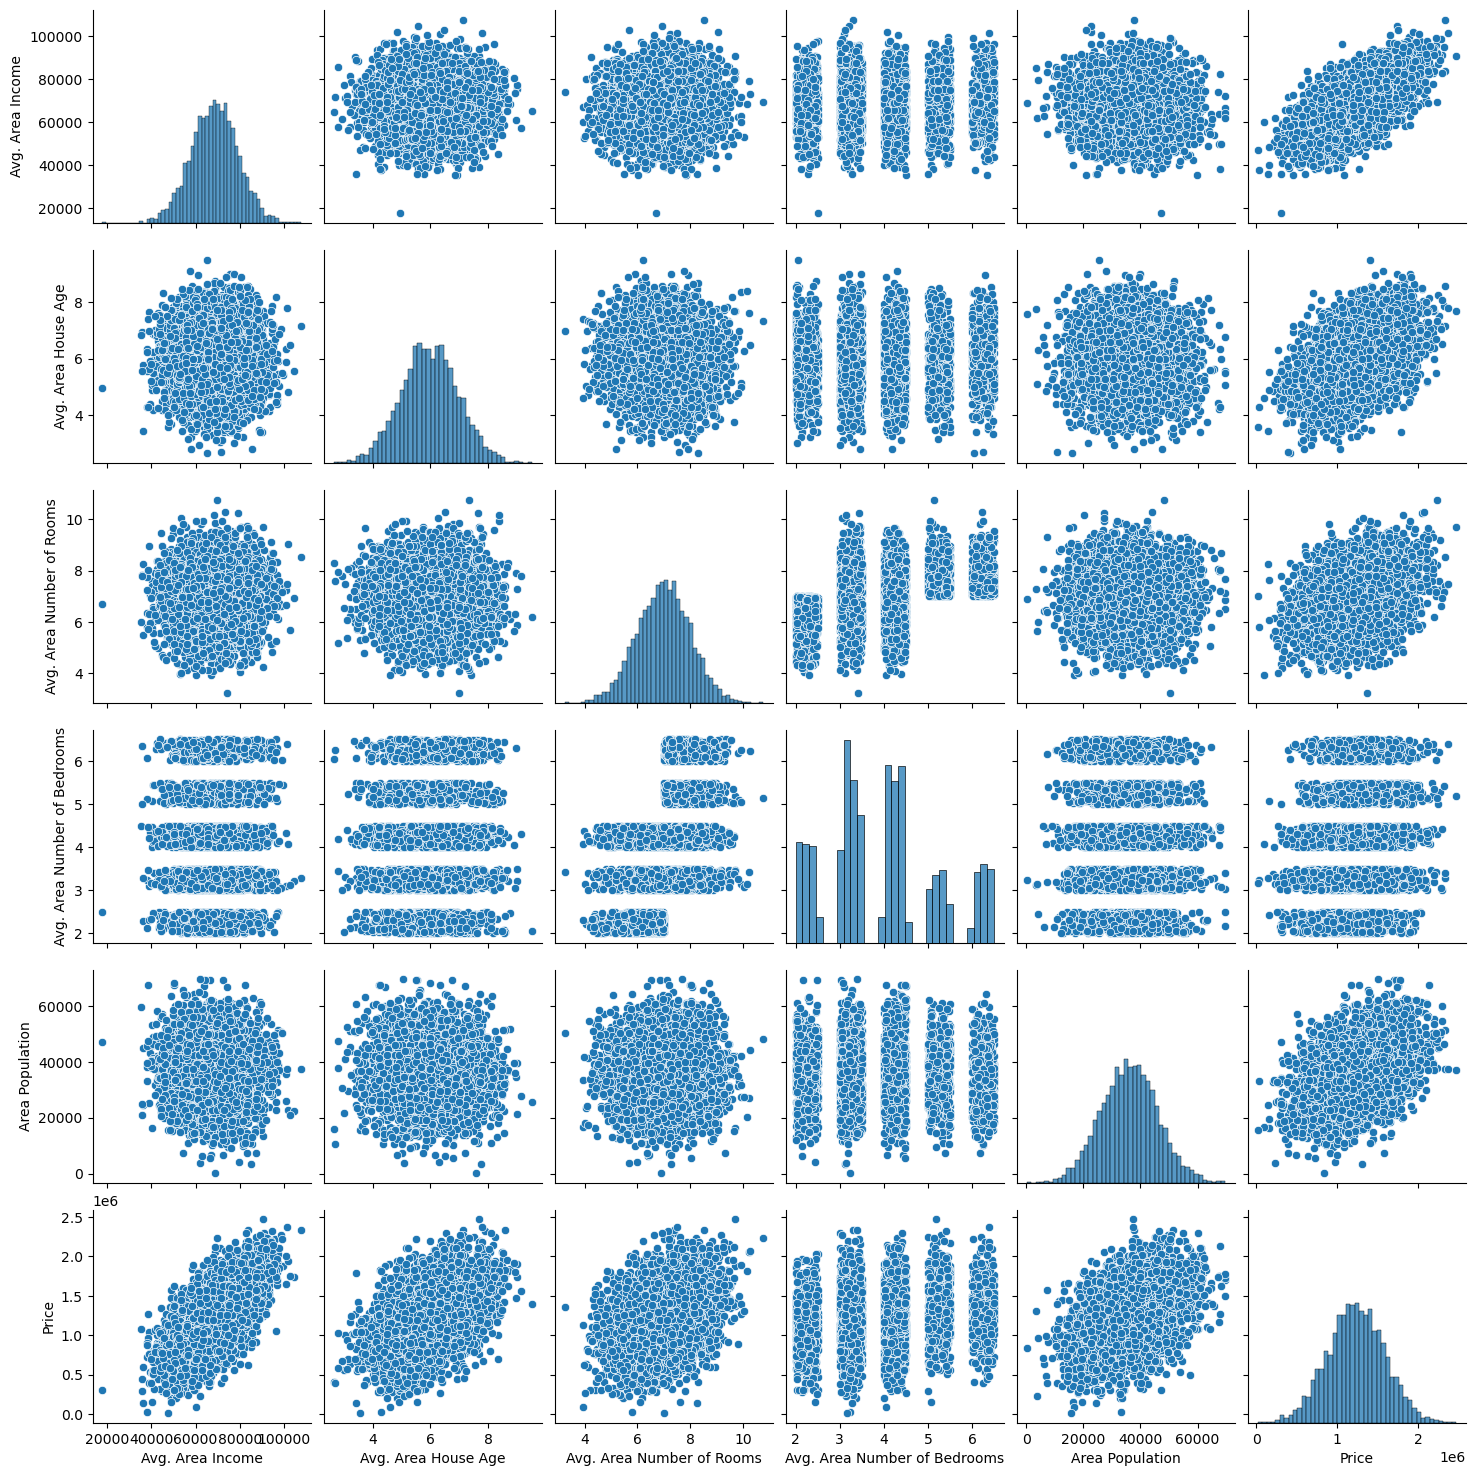

In [9]:
sns.pairplot(df.drop(columns=['Address']))
plt.show()

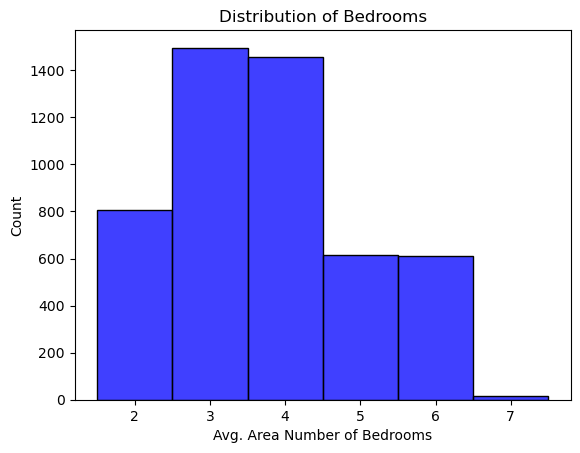

In [10]:
sns.histplot(df['Avg. Area Number of Bedrooms'], discrete=True, kde=False, color='blue')
plt.title('Distribution of Bedrooms')
plt.xlabel('Avg. Area Number of Bedrooms')
plt.ylabel('Count')
plt.show()

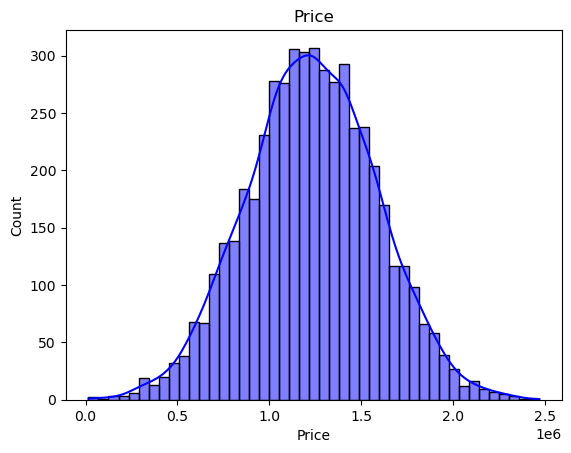

In [11]:
sns.histplot(df['Price'], edgecolor="black", linewidth=1, color='blue', kde=True)
plt.title('Price')
plt.xlabel('Price')
plt.ylabel('Count')
plt.show()

In [12]:
print(df.corr(numeric_only=True)['Price'].sort_values(ascending=False))

Price                           1.000000
Avg. Area Income                0.639734
Avg. Area House Age             0.452543
Area Population                 0.408556
Avg. Area Number of Rooms       0.335664
Avg. Area Number of Bedrooms    0.171071
Name: Price, dtype: float64


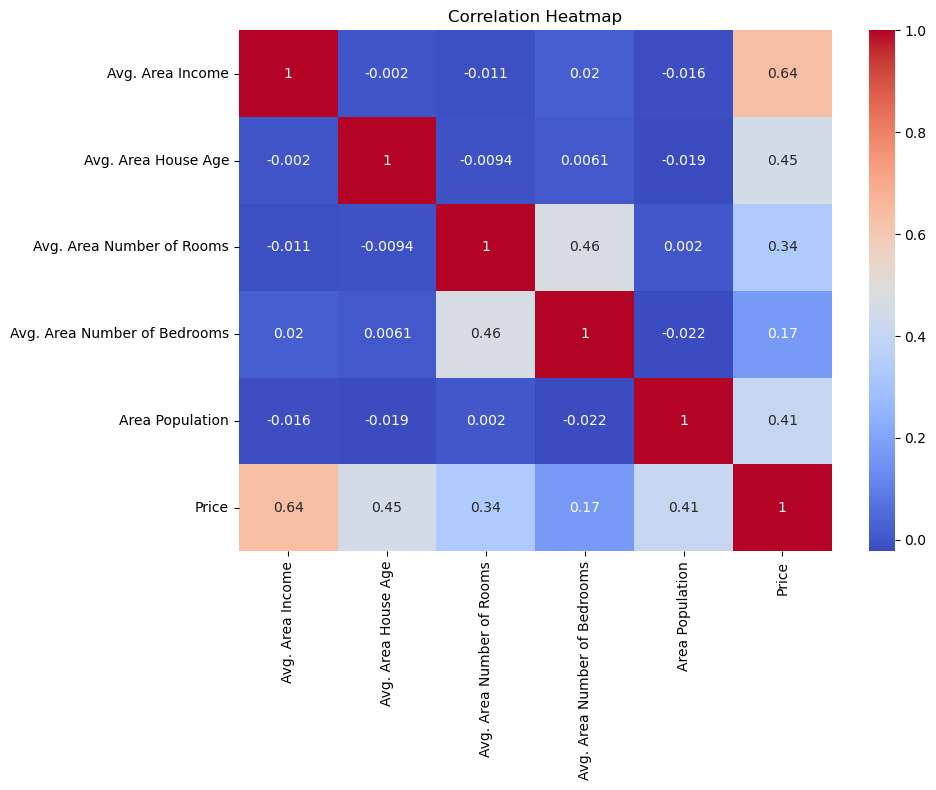

In [13]:
plt.figure(figsize=(10,8))
sns.heatmap(df.corr(numeric_only=True), annot=True, cmap='coolwarm')
plt.title('Correlation Heatmap')
plt.tight_layout()
plt.show()

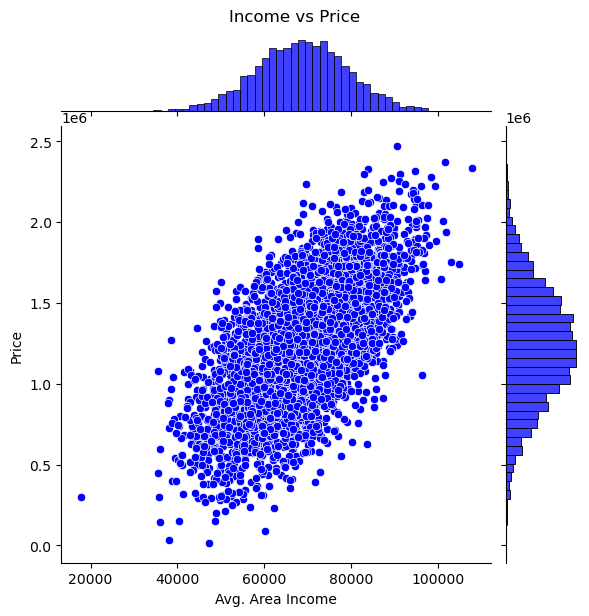

In [14]:
joint = sns.jointplot(x='Avg. Area Income', y='Price', data=df, color='blue')
joint.fig.suptitle('Income vs Price', y=1.02)
plt.show(joint)

## Step 5: Machine Learning: Training a Linear Regression Model
**Process**
1. Selecting and split features X and target pricing Y.
2. Split dataset into **60% Training** and **40% Testing** subsets.
3. Initialize and `fit` a `LinearRegression` model.
4. Generate and evaluate performance via RMSE, MSE, MAE metric graphs.

**Model:** We used factor such as *Avg. Area Income*, *Avg. Area House Age*, *Avg. Area Number of Rooms*, and *Area Population* to accurately predict  property *Price*.

In [15]:
df.columns

Index(['Avg. Area Income', 'Avg. Area House Age', 'Avg. Area Number of Rooms',
       'Avg. Area Number of Bedrooms', 'Area Population', 'Price', 'Address'],
      dtype='object')

In [16]:
X = df[['Avg. Area Income', 'Avg. Area House Age', 'Avg. Area Number of Rooms',
       'Avg. Area Number of Bedrooms', 'Area Population']]
y = df['Price']

In [17]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.4, random_state=101)

In [18]:
model = LinearRegression().fit(X_train, y_train)

In [19]:
predictions = model.predict(X_test)

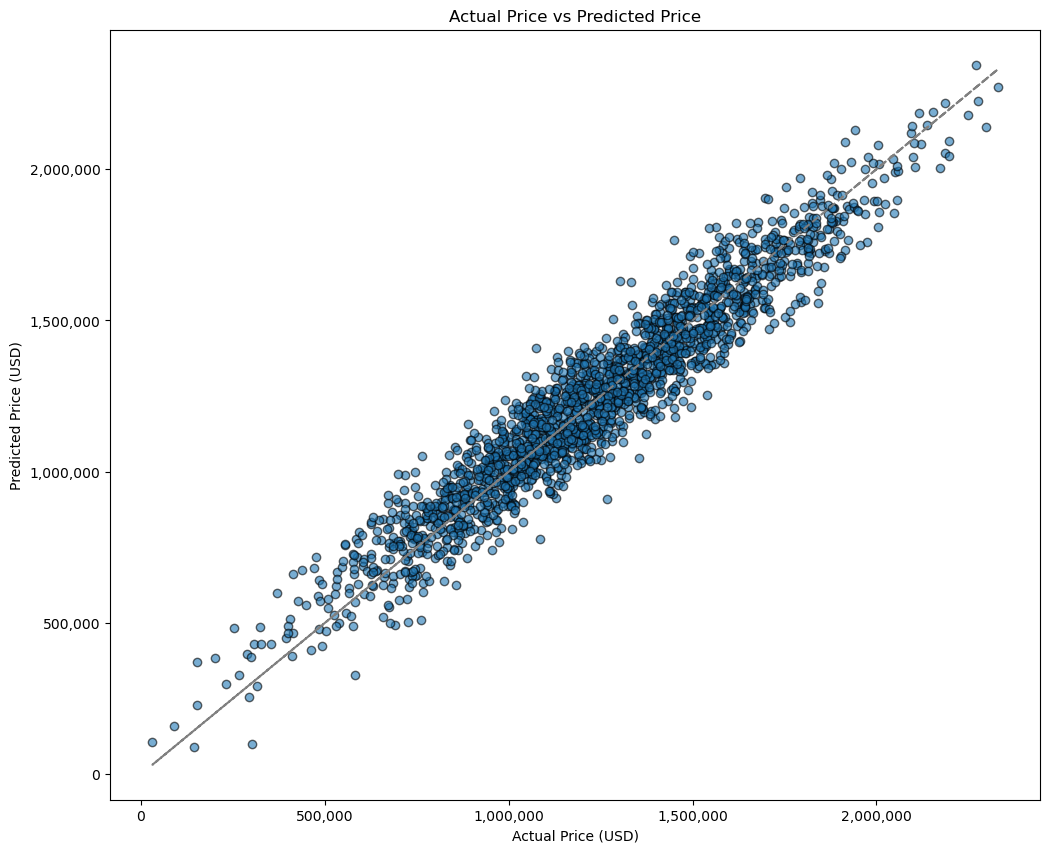

In [20]:
plt.figure(figsize=(12, 10))
plt.title("Actual Price vs Predicted Price")
plt.xlabel("Actual Price (USD)")
plt.ylabel("Predicted Price (USD)")
plt.scatter(y_test, predictions, edgecolor='black', alpha=0.6)
plt.gca().xaxis.set_major_formatter("{x:,.0f}")
plt.gca().yaxis.set_major_formatter("{x:,.0f}")
plt.plot(y_test, y_test, color="gray", ls="--")
plt.show()

In [22]:
print('MAE:', metrics.mean_absolute_error(y_test, predictions))
print('MSE:', metrics.mean_squared_error(y_test, predictions))
print('RMSE:', np.sqrt(metrics.mean_squared_error(y_test, predictions)))
((metrics.mean_absolute_error(y_test, predictions)) / df['Price'].mean()) * 100

MAE: 82288.22251914958
MSE: 10460958907.209684
RMSE: 102278.82922291242


np.float64(6.678844972533721)

In [26]:
percentage_error = ((metrics.mean_absolute_error(y_test, predictions)) / (df['Price'].mean())) * 100
print(f"Average Percentage Error: {percentage_error:}%")
print(f"Overall Model Accuracy Rate: {100 - percentage_error:}%")

Average Percentage Error: 6.678844972533721%
Overall Model Accuracy Rate: 93.32115502746628%


### What do these numbers mean?
* **MAE:** On average, our model's price predictions are off by about **$82,288**.
  
* **RMSE:** The model balances well, averaging **$102,278** in variance from true market prices. 
* Because the **RMSE** and **MAE** values Based on the RMSE being fairly close to MSE we can also tell that there isn't very many outliers

## Step 6: Advanced Analysis: K-Means Class Markets
Unsupervised machine learning ($K=3$) to cluster neighborhoods into three different classes **Low**, **Mid**, **High**


In [24]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(df.drop(['Price', 'Address'], axis=1))
kmeans = KMeans(n_clusters=3, random_state=27, n_init=10)
kmeans.fit(X_scaled)
cluster_map = {
    0: 'Mid-Tier',
    1: 'High-Tier',
    2: 'Low-Tier'
}
df['Cluster'] = kmeans.labels_
print("Neighborhood Counts per Cluster:")
print(df['Cluster'].value_counts())

Neighborhood Counts per Cluster:
Cluster
1    1757
0    1726
2    1517
Name: count, dtype: int64


<Figure size 1400x900 with 0 Axes>

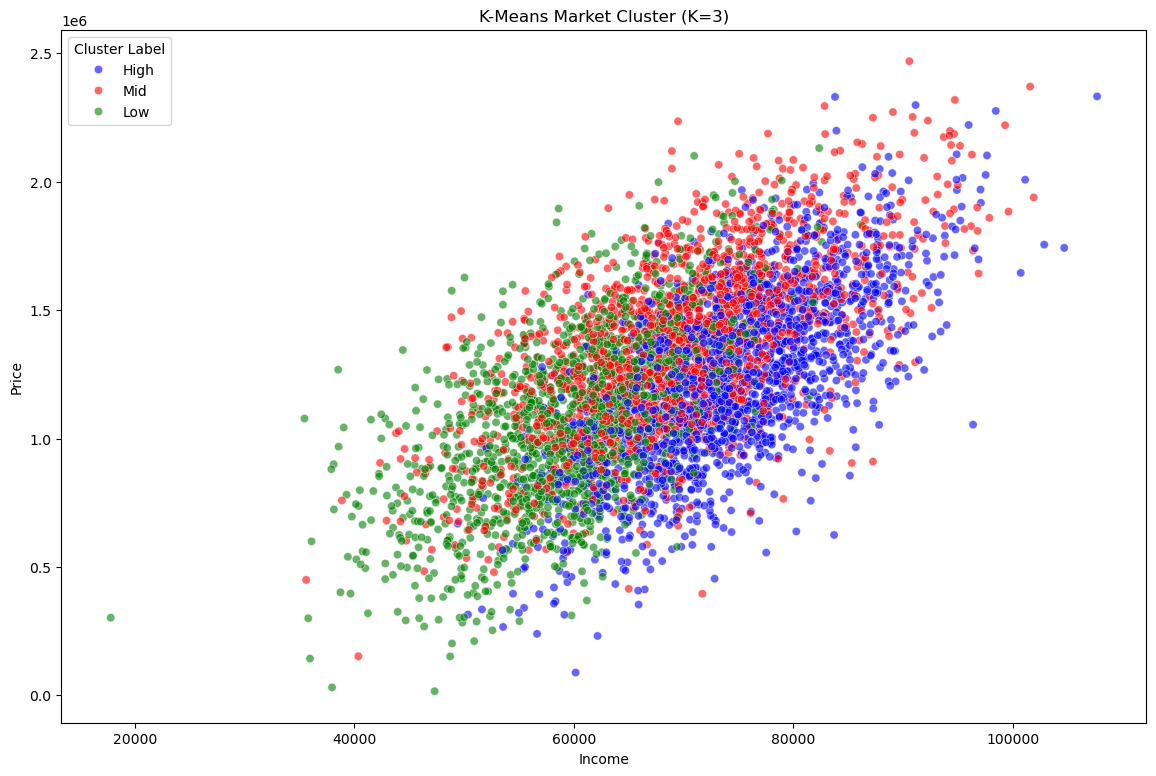

In [31]:
plt.figure(figsize=(14, 9))

df['Cluster Label'] = df['Cluster'].map({0: 'Mid', 1: 'High', 2: 'Low'})

sns.scatterplot(data=df, x='Avg. Area Income', y='Price', hue='Cluster Label',
                palette={'Low': 'green', 'Mid': 'red', 'High': 'blue'}, alpha=0.6)

plt.title('K-Means Market Cluster (K=3)')
plt.xlabel('Income')
plt.ylabel('Price')
plt.show()